# Pandas

__Content__
- [Overviewing the data](#Overview-of-the-Data)
- [Indexes](#Indexes)
- [Filtering Data](#Filtering-Data)
- [Updating Rows and Columns](#Updating-Rows-and-Columns)
- [Adding and Remove Columns](#Add-and-Remove:-Columns)
- [Adding and Removing Rows](#Add-and-Remove:-Rows)
- [apply(), map(), replace()](#updating-rows:-apply(),-map(),-replace())
- [Sorting Data](#Sorting-data)
- [Statistics](#Statistics)
- [Grouping data](#Grouping-Data)
- [Cleaning data](#Cleaning-Data)
- [DateTime](#Working-with-DateTime)
- [Filtering Datetime](#Filtering-Datetime)
- [Re-Sampling](#Re-sampling)

__Importing Libraries__

In [5]:
import numpy as np
import pandas as pd

__Importing csv data__

In [6]:
pathname = "/workspaces/codespaces-jupyter/data/stack-overflow-developer-survey-2025/survey_results_public.csv.zip"
schema_pathname = "/workspaces/codespaces-jupyter/data/stack-overflow-developer-survey-2025/survey_results_schema.csv"
df = pd.read_csv(pathname)

/tmp/ipykernel_57908/4163903758.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pathname)


__Some configurations__

In [7]:
pd.set_option('display.max_columns', 84)
#pd.set_option('display.max_rows', 80)

- __df__  : Real life dataset (from stackoverlflow).
- __dff__ : Test data for practice. 

__Pandas data structures studied so far.__
- Series
- DataFrame
- SeriesGroupBy
- DataFrameGroupBy
- pandas.core.resample.DatetimeIndexResampler

## Overview of the Data

In [8]:
df.shape

(48778, 172)

In [9]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=172)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48778 entries, 0 to 48777
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), object(120)
memory usage: 64.0+ MB


In [11]:
# Display first 5 rows. (remember we don't need to pass 5, it's default.)
df.head(5)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## Accessing data

In [12]:
df['Age']

0        25-34 years old
1        25-34 years old
2        35-44 years old
3        35-44 years old
4        35-44 years old
              ...       
48773    18-24 years old
48774    45-54 years old
48775    35-44 years old
48776    25-34 years old
48777    18-24 years old
Name: Age, Length: 48778, dtype: object

In [13]:
df[['Age', 'EdLevel', 'Employment']]

,Age,EdLevel,Employment
0,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em..."
3,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed
4,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em..."
...,...,...,...
48773,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed
48774,45-54 years old,Some college/university study without earning ...,Employed
48775,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed
48776,25-34 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Independent contractor, freelancer, or self-em..."


In [14]:
df[0:3]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

### Accessing data: iloc and loc
- df.loc[]
    - [list], [list]
    - sl:ce, sl:ce
    - [list], sl:ce
    - sl:ce, [list] 

In [15]:
df.loc[1]

ResponseId                                                             2
MainBranch                                I am a developer by profession
Age                                                      25-34 years old
EdLevel                              Associate degree (A.A., A.S., etc.)
Employment                                                      Employed
                                             ...                        
AIAgentExtWrite                                                      NaN
AIHuman                When I don’t trust AI’s answers;When I want to...
AIOpen                                         All skills. AI is a flop.
ConvertedCompYearly                                             104413.0
JobSat                                                               9.0
Name: 1, Length: 172, dtype: object

In [16]:
df.loc[[0, 2, 4]]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,12.0,"Developer, front-end",NaN,NaN,NaN,No,Work,12.0,2.0,3.0,7.0,5.0,10.0,13.0,1.0,4.0,14.0,NaN,8.0,1.0,2.0,12.0,13.0,3.0,9.0,4.0,11.0,15.0,NaN,Software Development,9.0,...,11.0,15.0,NaN,Neutral,About half of the time,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks,Documenting code;Debugging or fixing code;Test...,NaN,Project planning;Committing and reviewing code...,Learning about a codebase;Writing code;Generat...,NaN,"AI solutions that are almost right, but not qu...",No,"Yes, I use AI agents at work weekly","Yes, somewhat",Software engineering,Multi-platform search enablement,AI agents have increased my productivity.;AI a...,AI agents have improved the quality of my code...,AI agents have improved collaboration within m...,NaN,NaN,It takes signific

In [17]:
df.loc[1:3]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,12.0,"Developer, front-end",NaN,NaN,NaN,No,Work,12.0,2.0,3.0,7.0,5.0,10.0,13.0,1.0,4.0,14.0,NaN,8.0,1.0,2.0,12.0,13.0,3.0,9.0,4.0,11.0,15.0,NaN,Software Development,9.0,...,11.0,15.0,NaN,Neutral,About half of the time,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks,Documenting code;Debugging or fixing code;Test...,NaN,Project planning;Committing and reviewing code...,Learning about a codebase;Writing code;Generat...,NaN,"AI solutions that are almost right, but not qu...",No,"Yes, I use AI agents at work weekly","Yes, somewhat",Software engineering,Multi-platform search enablement,AI agents have increased my productivity.;AI a...,AI agents have improved the quality of my code...,AI agents have improved collaboration within m...,NaN,NaN,It takes significant time and effort to learn ...,My company's IT and/or InfoSec teams have stri...,NaN,I am concerned about the accuracy of the infor...,NaN,Redis,NaN,NaN,NaN,NaN,NaN,ChatGPT;Claud

In [18]:
df.loc[[1, 2], ['Age', 'Employment']]

,Age,Employment
1,25-34 years old,Employed
2,35-44 years old,"Independent contractor, freelancer, or self-em..."


In [19]:
df.loc[1:2, 'Age':'RemoteWork']

,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi..."
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,12.0,"Developer, front-end",NaN,NaN,NaN


In [20]:
df.loc[1:2, ['Age','EdLevel', 'LearnCode']]

,Age,EdLevel,LearnCode
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",Online Courses or Certification (includes all ...
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Online Courses or Certification (includes all ...


__With iloc[] we can use indexes for columns as well.__
- 'i' in iloc denotes integer.

In [21]:
df.iloc[1:3, 3:6]

,EdLevel,Employment,EmploymentAddl
1,"Associate degree (A.A., A.S., etc.)",Employed,NaN
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above


## Indexes

### Getting Indexes

In [22]:
print(type(df.index))
df.index

<class 'pandas.core.indexes.range.RangeIndex'>


RangeIndex(start=0, stop=48778, step=1)

In [23]:
# Return index of people earning $2000000 yearly.
df.loc[df['ConvertedCompYearly'] > 2000000].index

Index([ 5410, 10025, 14873, 19536, 24900, 25268, 27642, 27645, 28287, 30315,
       33854, 34940, 36939, 38936, 40005, 42730, 45558, 47610, 48015],
      dtype='int64')

### Indexes: Setting and Resetting indexes

In [24]:
df.set_index('ResponseId', inplace=True)

__method 2__

In [25]:
schema_df = pd.read_csv(schema_pathname, index_col = "qname")
schema_df.loc['Employment']

qid                                                      QID7
question    Which of the following best describes your cur...
type                                                       MC
sub                                                       NaN
sq_id                                                     NaN
Name: Employment, dtype: object

In [26]:
df.head()

,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
ResponseId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,8.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accur

In [27]:
df.loc[1]

MainBranch                              I am a developer by profession
Age                                                    25-34 years old
EdLevel                Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
Employment                                                    Employed
EmploymentAddl         Caring for dependents (children, elderly, etc.)
                                            ...                       
AIAgentExtWrite                                                    NaN
AIHuman                                When I don’t trust AI’s answers
AIOpen                           Troubleshooting, profiling, debugging
ConvertedCompYearly                                            61256.0
JobSat                                                            10.0
Name: 1, Length: 171, dtype: object

In [28]:
# Resetting indexes to default
df.reset_index(inplace=True)

### Indexes: Sorting indexes

In [29]:
schema_df.sort_index(inplace=True)

## Filtering Data

In [30]:
filt = df['LanguageHaveWorkedWith'] == 'Python'
df[filt][['ResponseId', 'Age', 'Employment']]

,ResponseId,Age,Employment
19,20,25-34 years old,"Independent contractor, freelancer, or self-em..."
181,182,18-24 years old,Student
679,680,18-24 years old,Employed
816,817,25-34 years old,Employed
1087,1088,65 years or older,Retired
...,...,...,...
47374,47788,25-34 years old,Employed
47590,48004,25-34 years old,Employed
47718,48132,55-64 years old,Employed
47979,48393,55-64 years old,Not employed


### Filtering Data: Using loc[ ]
- We can also select the columns that we want after filtering the data. Which is kinda cocky while using df[].

In [31]:
filt = df['LanguageHaveWorkedWith'] == 'C++'
df.loc[filt, ['ResponseId', 'Age', 'Employment']]

,ResponseId,Age,Employment
890,891,35-44 years old,Employed
1000,1001,35-44 years old,Employed
1014,1015,65 years or older,"Independent contractor, freelancer, or self-em..."
1148,1149,45-54 years old,Employed
1306,1307,65 years or older,"Independent contractor, freelancer, or self-em..."
...,...,...,...
43494,43908,18-24 years old,Student
45044,45458,35-44 years old,"Independent contractor, freelancer, or self-em..."
45419,45833,25-34 years old,Student
46794,47208,35-44 years old,Employed


In [32]:
filt = (df['LanguageHaveWorkedWith'] == 'C++') | (df['LanguageWantToWorkWith'] == "Python")
# '~' will negate the filter
df.loc[~filt]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [33]:
countries = ['United States of America', 'India', 'New Zealand', 'United Kingdom', 'Canada', 'Australia']
filt = df['Country'].isin(countries)

df.loc[filt, 'Country']

13                          India
15                          India
16                      Australia
21       United States of America
22       United States of America
                   ...           
48741                       India
48742                       India
48744    United States of America
48764    United States of America
48767                      Canada
Name: Country, Length: 12018, dtype: object

### Filter Data: String method

In [34]:
filt = df['LanguageHaveWorkedWith'].str.contains('Python', na=False)
df[filt]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,22.0,Engineering manager,NaN,NaN,NaN,"Yes, I endorsed a tool that was open-source an...",Work,6.0,3.0,1.0,9.0,10.0,8.0,7.0,4.0,2.0,14.0,NaN,7.0,13.0,3.0,9.0,12.0,6.0,1.0,8.0,14.0,15.0,NaN,Software Development,9.0,...,12.0,15.0,NaN,"No, not really","Rarely, almost never","Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks",Learning about a codebase;Writing code;Debuggi...,Project planning;Documenting code;Testing code...,Generating content or synthetic data,NaN,NaN,"AI solutions that are almost right, but not quite",partly,"No, and I don't plan to","Yes, to a great extent",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Integrating AI agents with my existing tools a...,NaN,I am concerned about the accuracy of the infor...,It takes significant time and effort to learn ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0
7,8,I am a developer by profession,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,Engaged in paid work (20-29 hours per week);Tr...,22.0,"Yes, I am not new to coding but am learning ne...",Books / Physical media;Technical documentation...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Blogs or p...,30.0,"Architect, software or solutions",Less than 20 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Personal Project,12.0,2.0,1.0,10.0,4.0,5.0,8.0,6.0,7.0,14.0,NaN,14.0,3.0,4.0,9.0,1.0,5.0,2.0,11.0,12.0,15.0,NaN,Software Development,7.0,...,11.0,15.0,NaN,"Yes, definitely",About half of the time,"Yes, I use AI tools daily",Very favorable,Somewhat trust,Neither good or bad at handling complex tasks,Writing code;Documenting code,NaN,Project planning;Debugging or fixing code;Depl...,Learning about a codebase;Testing code;Committ...,Search for answers;Learning new concepts or te...,"AI solutions that are almost right, but not qu...",Yes,"No, but I plan to","Yes, to a great extent",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have concerns about the security and privacy...,I am concerned about the accuracy of the infor...,The cost of using certain AI agent platforms i...,Integrating AI agents with my existing tools a...,NaN,NaN,N

## Updating Rows and Columns

In [35]:
people = {
    "first":["Sunyog", "Suyog", "Saurabh", "Ansh"],
    "last":["Lodhi", "Lodhi", "Patel", "Goswami"],
    "age" : [22, 23, 23, 21],
    "email" : ["sunyoglodhi@example.com", "lodhisuyog@example.com", "lsaurabh28@example.com", "goansh1@example.com"]

}

dff = pd.DataFrame(people)
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


### Updating Columns names

Updating all the column headers.

In [36]:
dff.columns = ["first_name", "last_name", "age", "Email"]
dff.head()

,first_name,last_name,age,Email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


Or we can use list comprehension to apply some function to all the columns.

In [37]:
dff.columns = [col_name.lower() for col_name in dff.columns]
dff.head()

,first_name,last_name,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


In [38]:
dff.columns = dff.columns.str.replace(" ", "_")
dff.head()

,first_name,last_name,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


### Update columns: rename()

In [39]:
dff.rename(columns={"first_name":"first", "last_name":"last"}, inplace=True)
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


### Updating Rows

In [40]:
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Ansh,Goswami,21,goansh1@example.com


Modifying complete row. 

In [41]:
dff.loc[3] = ["Siddhant", "Patel", 25, "siddthakur25@example.com"]
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Patel,25,siddthakur25@example.com


Modifying multiple elements of the row. 

In [42]:
dff.loc[3, ['last', 'age']] = ["Thakur", 26]
dff.loc[3]

first                    Siddhant
last                       Thakur
age                            26
email    siddthakur25@example.com
Name: 3, dtype: object

Modifying single element of row.

In [43]:
dff.loc[3, 'age'] = 25

### Updating Rows: Using Filters

In [44]:
filt = (dff['first'] == "Suyog") & (dff['age'] == 24)
dff.loc[filt, 'age'] = 24
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


Updating a specific attribute of all the column (Updating a column value)

In [45]:
dff['email'] = dff['email'].str.lower()
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


## updating rows: apply(), map(), replace()

In [46]:
array = ['apply', 'map', 'applymap', 'replace']
array1 = map(len, array)
print(list(array1))

[5, 3, 8, 7]


### apply()
- Running __apply()__ on a __series__ applies a function to __every value__ in the series.
- Running __apply()__ on a __dataframes__ applies a function to every __row series__ in dataframe.

__apply() on a series.__

In [47]:
dff['email'] = dff['email'].apply(lambda email: email.lower())

__apply() on a dataframe__

In [48]:
# dff.apply(lambda series: series.min())
dff.apply(pd.Series.min)

first                   Saurabh
last                      Lodhi
age                          22
email    lodhisuyog@example.com
dtype: object

### applymap() (deprecated, use map())

In [49]:
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


__applymap()__ is used to apply a function to __every element__ of a __dataframe__. Ofcourse __this does not work on a series__ because when we use __apply()__ on a series, it means we're applying that function to every element of the series. 

In [50]:
dff.loc[:, 'first': 'last'].applymap(str.upper)

/tmp/ipykernel_57908/13845752.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dff.loc[:, 'first': 'last'].applymap(str.upper)


,first,last
0,SUNYOG,LODHI
1,SUYOG,LODHI
2,SAURABH,PATEL
3,SIDDHANT,THAKUR


In [51]:
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


### map()

__map() on series.__
- Map values of Series according to an input mapping or function.
- Used for __substituting__ each value in a Series with another value, that may be derived from a __function, a dict or a Series.__

If __dictionary__ is passed it'll __replace keys with values__, but if all the values are not specified than it'll replace them with 'NaN'.

In [52]:
dff['first'].map({"Sunyog": "Corey", "Siddhant":"Michael"}, na_action = 'ignore')

0      Corey
1        NaN
2        NaN
3    Michael
Name: first, dtype: object

if __function()__ is passed it'll apply that function to all the elements of a series. 

In [53]:
dff['first'].map(str.upper)

0      SUNYOG
1       SUYOG
2     SAURABH
3    SIDDHANT
Name: first, dtype: object

__map() on dataframe__
- Apply a function to a Dataframe elementwise.
- Used instead of applymap()

In [54]:
dff.loc[:, "first":"last"].map(str.upper)

,first,last
0,SUNYOG,LODHI
1,SUYOG,LODHI
2,SAURABH,PATEL
3,SIDDHANT,THAKUR


### replace()

__replace() on a series__.

In [55]:
# However if you only want to replace specific values and retain other values as well, you should use replace() instead of map().
dff['first'].replace({"Sunyog":"Corey", "Siddhant":"Michael"})

0      Corey
1      Suyog
2    Saurabh
3    Michael
Name: first, dtype: object

In [56]:
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


In [57]:
# Replace all the values that match specified value.
# Any element in the dataframe which is equal to 'Lodhi' will be replaced with 'Patel', irrespective of row or column. 
dff.replace('Lodhi', "Patel")

,first,last,age,email
0,Sunyog,Patel,22,sunyoglodhi@example.com
1,Suyog,Patel,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


In [58]:
# Replace 'Sunyog' to 'Corey' and 'Lodhi' to 'Singh', everywhere in the dataframe
dff.replace({"Sunyog": "Corey", "Lodhi": "Singh"})

,first,last,age,email
0,Corey,Singh,22,sunyoglodhi@example.com
1,Suyog,Singh,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


In [59]:
# Replace 24, 23, and 25 with 69, everywhere in the dataframe. 
dff.replace([24, 23, 25], 69)

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,69,lodhisuyog@example.com
2,Saurabh,Patel,69,lsaurabh28@example.com
3,Siddhant,Thakur,69,siddthakur25@example.com


In [60]:
# A[i] = B[i], everywhere in the dataframe.
dff.replace([22, 24, 23], [32, 34, 33])

,first,last,age,email
0,Sunyog,Lodhi,32,sunyoglodhi@example.com
1,Suyog,Lodhi,33,lodhisuyog@example.com
2,Saurabh,Patel,33,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


In [61]:
# Replace 'Sunyog' from Column 'first' and 'Thakur' from column 'last' to 'Corey'.
# dff.replace({'first':"Sunyog"}, "Corey")
dff.replace({'first':"Sunyog", 'last':"Thakur"}, "Corey")

,first,last,age,email
0,Corey,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Corey,25,siddthakur25@example.com


In [62]:
# In column first, Change 'Sunyog' to 'Michael' and 'Siddhant' to 'Prasoon'.
dff.replace({'first': {'Sunyog':"Michael", 'Siddhant': 'Prasoon'}})

,first,last,age,email
0,Michael,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Prasoon,Thakur,25,siddthakur25@example.com


## Add and Remove: Columns

In [63]:
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,Patel,23,lsaurabh28@example.com
3,Siddhant,Thakur,25,siddthakur25@example.com


### Adding Columns

In [64]:
# combining two columns into a new column.
dff['fullname'] = dff['first'] + " " + dff["last"]
dff.head()

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur


In [65]:
# One hell of a way to split a column into two new columns (NOT RECOMMENDED).
dff['first'] = [x[0] for x in dff['fullname'].str.split(' ')]
dff['last'] = [x[1] for x in dff['fullname'].str.split(' ')]
dff.head()

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur


In [66]:
dff[['first', 'last']] = dff['fullname'].str.split(" ", expand=True)
dff.head()

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur


### Dropping Columns

In [67]:
# You can add "inplace=True" as an argument, I am not doing it here, cause it will mess up the data. 
# Output is what we will be left with.
dff.drop(columns = ['first', 'last'])

,age,email,fullname
0,22,sunyoglodhi@example.com,Sunyog Lodhi
1,23,lodhisuyog@example.com,Suyog Lodhi
2,23,lsaurabh28@example.com,Saurabh Patel
3,25,siddthakur25@example.com,Siddhant Thakur


## Add and Remove: Rows

### Adding Rows

In [68]:
# Recommended
# (_append() does not have inplace arguemnt)
new_field = {'first':"Suyash", 'age':21, "last":"Shrivastava"}
dff = dff._append(new_field, ignore_index=True)
dff.head()

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur
4,Suyash,Shrivastava,21,NaN,NaN


In [69]:
# All the element should match the row element of the dataframe (Not much useful)
dff.loc[5] = ['Samriddhi', 'Dubey', 19, 'riddhisam@example.com', 'Samriddhi Dubey']
dff

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur
4,Suyash,Shrivastava,21,NaN,NaN
5,Samriddhi,Dubey,19,riddhisam@example.com,Samriddhi Dubey


__Combining two DataFrame into the first DataFrame by appending all the rows of second DataFrame into first DataFrame.__

In [70]:
dataframe = {
    'first': ['John', 'Martin'],
    'last' : ['winster', 'luther'],
    'age' : [34, 37]
}
dff2 = pd.DataFrame(dataframe)

In [71]:
dff = dff._append(dff2, ignore_index=True, sort=False)
dff

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur
4,Suyash,Shrivastava,21,NaN,NaN
5,Samriddhi,Dubey,19,riddhisam@example.com,Samriddhi Dubey
6,John,winster,34,NaN,NaN
7,Martin,luther,37,NaN,NaN


### Droping rows

In [72]:
dff.drop(index=[6,7], inplace=True)
dff

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur
4,Suyash,Shrivastava,21,NaN,NaN
5,Samriddhi,Dubey,19,riddhisam@example.com,Samriddhi Dubey


### Deleting rows: using conditions

In [73]:
filt = (dff['age'] == 19) | (dff['age'] == 21)
dff.drop(index = (dff.loc[filt].index), inplace=True)
dff

,first,last,age,email,fullname
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur


## Sorting data

In [74]:
dff.sort_values(by=['last', 'age'], ascending=[False, True], inplace=False)

,first,last,age,email,fullname
3,Siddhant,Thakur,25,siddthakur25@example.com,Siddhant Thakur
2,Saurabh,Patel,23,lsaurabh28@example.com,Saurabh Patel
0,Sunyog,Lodhi,22,sunyoglodhi@example.com,Sunyog Lodhi
1,Suyog,Lodhi,23,lodhisuyog@example.com,Suyog Lodhi


In [75]:
df.sort_values(by=['Country', 'ConvertedCompYearly'], ascending=[True, False], inplace=True)

In [76]:
df[['Country', 'ConvertedCompYearly']].head(15)

,Country,ConvertedCompYearly
40553,Afghanistan,65000.0
39893,Afghanistan,9858.0
7076,Afghanistan,8450.0
45511,Afghanistan,7042.0
7166,Afghanistan,5200.0
38195,Afghanistan,1000.0
6009,Afghanistan,986.0
7924,Afghanistan,282.0
6835,Afghanistan,NaN
15707,Afghanistan,NaN


In [77]:
# To sort the indexes of the dataframe. 
df.sort_index(inplace=True)

In [78]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## First 'n' max & 'n' min

In [79]:
# To get the first '15' people with highest 'ConvertedCompYearly'
# df.nlargest(15, 'ConvertedCompYearly')
df['ConvertedCompYearly'].nlargest(15)

33854    50000000.0
28287    33552715.0
42730    18387548.0
34940    15430267.0
45558    13921760.0
48015    10000000.0
24900     9531653.0
10025     9000000.0
36939     6890299.0
30315     6371285.0
40005     6000000.0
19536     5810837.0
27642     5000000.0
14873     4706124.0
47610     3900562.0
Name: ConvertedCompYearly, dtype: float64

In [80]:
# df.nsmallest(15, 'ConvertedCompYearly')
df['ConvertedCompYearly'].nsmallest(15)

90       1.0
1764     1.0
4580     1.0
5910     1.0
8405     1.0
9012     1.0
12407    1.0
12559    1.0
12980    1.0
13304    1.0
14468    1.0
16489    1.0
20026    1.0
21034    1.0
26961    1.0
Name: ConvertedCompYearly, dtype: float64

## Statistics

In [81]:
df['ConvertedCompYearly'].mean()

np.float64(101806.08927291886)

In [82]:
df.median(skipna=True, numeric_only=True)

WorkExp                    10.0
YearsCode                  14.0
TechEndorse_1               9.0
TechEndorse_2               4.0
TechEndorse_3               4.0
TechEndorse_4               6.0
TechEndorse_5               4.0
TechEndorse_6               5.0
TechEndorse_7               7.0
TechEndorse_8               4.0
TechEndorse_9               4.0
TechEndorse_13             10.0
TechOppose_1                9.0
TechOppose_2                4.0
TechOppose_3                6.0
TechOppose_5                5.0
TechOppose_7                4.0
TechOppose_9                3.0
TechOppose_11               4.0
TechOppose_13               5.0
TechOppose_16               6.0
TechOppose_15              10.0
JobSatPoints_1              6.0
JobSatPoints_2              4.0
JobSatPoints_3              7.0
JobSatPoints_4             10.0
JobSatPoints_5             10.0
JobSatPoints_6              8.0
JobSatPoints_7              5.0
JobSatPoints_8              7.0
JobSatPoints_9              6.0
JobSatPo

Mean is affected greatly by outliers. It's better to use median, to prevent outliers affectiing the data. 
count represent number of 'non-na' row.

In [83]:
# df['ConvertedCompYearly'].describe()
df.describe()

,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,ToolCountWork,ToolCountPersonal,CompTotal,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,42546.000000,42664.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,35639.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,33932.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,27337.000000,25339.000000,2.463500e+04,25998.000000,24078.000000,25998.000000,25998.000000,25998.000000,25998.000000,25998.000000,25998.000000,25998.000000,25998.000000,2.372500e+04,26426.000000
mean,13.373643,16.577653,7.869272,4.104801,4.109262,5.680098,4.121889,5.227953,6.477819,4.371756,4.431802,9.856646,8.310002,4.521897,5.924526,4.995108,4.050778,3.801692,4.366262,5.060886,5.512083,9.948603,6.866624,5.219003,7.456580,9.539212,9.755422,8.191931,5.883296,7.369456,6.747693,7.509631,5.703181,8.563330,8.679063,14.688532,7.827048,17.830047,8.565768,2.255147e+70,4.909070,3.340684,5.719363,4.565428,4.790676,5.199554,5.676706,4.987461,7.098700,10.084122,1.018061e+05,7.202528
std,10.806001,11.791351,2.399480,2.277716,2.330321,2.398953,2.438574,2.801404,2.334073,2.357658,2.621363,1.979287,2.204737,2.284106,2.304370,2.297027,2.609786,2.501696,2.557097,2.536174,2.906671,2.092258,3.742319,3.662974,3.724744,3.779333,3.557774,3.800563,3.901354,4.118185,3.889358,3.846450,4.111374,3.546273,3.634408,1.894720,4.078976,271.156358,44.870254,3.539576e+72,2.683702,2.411901,2.628916,3.071848,2.644689,2.564885,2.313620,2.492670,2.474463,1.942345,4.637975e+05,1.996800
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,2.000000,2.000000,10.000000,8.000000,3.000000,4.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,10.000000,4.000000,2.000000,4.000000,7.000000,7.000000,5.000000,2.000000,4.000000,3.000000,4.000000,2.000000,6.000000,6.000000,15.000000,4.000000,4.000000,3.000000,5.500000e+04,3.000000,1.000000,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.820600e+04,6.000000
50%,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,4.000000,4.000000,10.000000,9.000000,4.000000,6.000000,5.000000,4.000000,3.000000,4.000000,5.000000,6.000000,10.000000,6.000000,4.000000,7.000000,10.000000,10.000000,8.000000,5.000000,7.000000,6.000000,7.000000,5.000000,9.000000,9.000000,15.000000,8.000000,6.000000,5.000000,1.050000e+05,5.000000,2.000000,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.529400e+04,8.000000
75%,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,6.000000,7.000000,10.000000,9.000000,6.000000,8.000000,7.000000,6.000000,6.000000

In [84]:
# df.value_counts('SurveyEase')
df['SurveyEase'].value_counts()

KeyError: 'SurveyEase'

In [ ]:
df['EdLevel'].value_counts(normalize=True)

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          0.417242
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       0.233515
Some college/university study without earning a degree                                0.133598
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    0.101133
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        0.044184
Associate degree (A.A., A.S., etc.)                                                   0.031908
Primary/elementary school                                                             0.021654
Something else                                                                        0.016767
Name: proportion, dtype: float64

## Grouping Data

Useful methods that can be used on a Grouped DataFrame:
- DataFrameGroupBy.__get_group()__
- DataFrameGroupBy.__count()__
- DataFrameGroupBy.__agg()__
- DataFrameGroupBy.__apply()__

In [ ]:
country_group = df.groupby('Country')
print(country_group)

In [ ]:
country_group.get_group("United States of America")

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,TechList,BuyNewTool,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,AISearchHaveWorkedWith,AISearchWantToWorkWith,AIDevHaveWorkedWith,AIDevWantToWorkWith,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOComm,SOAI,AISelect,AISent,AIAcc,AIBen,AIToolInterested in Using,AIToolCurrently Using,AIToolNot interested in Using,AINextVery different,AINextNeither different nor similar,AINextSomewhat similar,AINextVery similar,AINextSomewhat different,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,Other,18,9,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,I have a great deal of influence,Investigate,Start a free trial;Ask developers I know/work ...,United States of America,USD\tUnited States dollar,285000.0,HTML/CSS;JavaScript;Python,Bash/Shell (all shells);C#;Dart;Elixir;GDScrip...,Supabase,Firebase Realtime Database;Supabase,Amazon Web Services (AWS);Netlify;Vercel,Fly.io;Netlify;Render,Next.js;React;Remix;Vue.js,Deno;Elm;Nuxt.js;React;Svelte;Vue.js,Electron;React Native;Tauri,Capacitor;Electron;Tauri;Uno Platform;Xamarin,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Godot;npm;pnpm;Unity 3D;Unreal Engine;Vite;Web...,Vim;Visual Studio Code,Vim;Visual Studio Code,iOS;iPadOS;MacOS;Windows;Windows Subsystem for...,MacOS;Windows;Windows Subsystem for Linux (WSL),Asana;Basecamp;GitHub Discussions;Jira;Linear;...,GitHub Discussions;Linear;Notion;Trello,Cisco Webex Teams;Discord;Google Chat;Google M...,Discord;Signal;Slack;Zoom,ChatGPT,ChatGPT;Neeva AI,GitHub Copilot,GitHub Copilot,Stack Overflow;Stack Exchange,Daily or almost daily,Yes,A few times per month or weekly,"Yes, definitely","I don't think it's super necessary, but I thin...",Yes,Indifferent,Other (please explain),Somewhat distrust,Learning about a codebase;Writing code;Debuggi...,Writing code;Committing and reviewing code,NaN,NaN,NaN,NaN,NaN,NaN,Yes,People manager,10.0,Strongly agree,Agree,Strongly agree,Agree,Agree,Agree,Agree,Strongly agree,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,NaN,27,23,"Developer, back-end","5,000 to 9,999 employees",I have some influence,Given a list,Start a free trial;Ask developers I know/work ...,United States of America,USD\tUnited States dollar,250000.0,Bash/Shell (all shells);Go,Haskell;OCaml;Rust,NaN,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,NaN,NaN,NaN,NaN,Cargo;Docker;Kubernetes;Make;Nix,Cargo;Kubernetes;Nix,Emacs;Heli

In [ ]:
country_group.get_group('India').value_counts('EdLevel')

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          3452
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                        993
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     582
Some college/university study without earning a degree                                 348
Primary/elementary school                                                              113
Something else                                                                          63
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                          54
Associate degree (A.A., A.S., etc.)                                                     20
Name: count, dtype: int64

In [ ]:
# We can think of this as method-2 or what's really happening under the hood. 
filt = df['Country'] == 'India'
df.loc[filt, 'EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          3452
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                        993
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     582
Some college/university study without earning a degree                                 348
Primary/elementary school                                                              113
Something else                                                                          63
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                          54
Associate degree (A.A., A.S., etc.)                                                     20
Name: count, dtype: int64

In [ ]:
# WHAT IS THIS PART OF CODE DOING AND ACTUALLY MEAN?
country_group['LanguageHaveWorkedWith']
# A Series.GroupBy containing tuples which countains 'country name' and then all the 'LanguageHaveWorkedWith' values. 

__This is what the above code means.__

In [ ]:
df.loc[:, ['Country', 'LanguageHaveWorkedWith']].sort_values(by='Country')

,Country,LanguageHaveWorkedWith
21497,Afghanistan,HTML/CSS;JavaScript;TypeScript
65292,Afghanistan,Bash/Shell (all shells);C#;PowerShell;SQL;VBA
1334,Afghanistan,C;C++;Java;PHP
33927,Afghanistan,Python;SQL
77722,Afghanistan,C;C#;C++;Go;HTML/CSS;Zig
...,...,...
88820,NaN,NaN
88828,NaN,NaN
88830,NaN,NaN
89028,NaN,NaN


In [ ]:
country_group['EdLevel'].value_counts().head(20)

Country      EdLevel                                                                           
Afghanistan  Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20
             Something else                                                                        13
             Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     8
             Associate degree (A.A., A.S., etc.)                                                    6
             Primary/elementary school                                                              6
             Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                        5
             Some college/university study without earning a degree                                 4
             Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2
Albania      Bachelor’s degree (B.A., B.S., B.Eng., etc.)                               

In [ ]:
country_group

### DataFrameGroupBy.size() 
- Compute group sizes.




In [ ]:
country_group.size()

Country
Afghanistan                              64
Albania                                  60
Algeria                                  85
Andorra                                  16
Angola                                   13
                                       ... 
Venezuela, Bolivarian Republic of...    106
Viet Nam                                390
Yemen                                    20
Zambia                                   26
Zimbabwe                                 34
Length: 185, dtype: int64

### DataFrameGroupBy.count()
- Count of values within each group, excluding missing values.

In [ ]:
country_group['LanguageHaveWorkedWith'].count()

Country
Afghanistan                              58
Albania                                  55
Algeria                                  83
Andorra                                  15
Angola                                   11
                                       ... 
Venezuela, Bolivarian Republic of...    103
Viet Nam                                380
Yemen                                    18
Zambia                                   26
Zimbabwe                                 33
Name: LanguageHaveWorkedWith, Length: 185, dtype: int64

### DataFrameGroupBy.apply()

In [ ]:
country_group['LanguageHaveWorkedWith'].apply(lambda x: x + " END")

Country           
Afghanistan  1334                                    C;C++;Java;PHP END
             2300                                       Java;Python END
             2641     Bash/Shell (all shells);JavaScript;Python;SQL END
             3910                                              Perl END
             4221     C;C#;C++;Dart;HTML/CSS;Java;JavaScript;Kotlin;...
                                            ...                        
Zimbabwe     78740                              HTML/CSS;JavaScript END
             81437    Bash/Shell (all shells);HTML/CSS;JavaScript;Ty...
             81950                                             Rust END
             86365    C++;HTML/CSS;JavaScript;PHP;PowerShell;Python;...
             88573      Bash/Shell (all shells);HTML/CSS;Python;SQL END
Name: LanguageHaveWorkedWith, Length: 87973, dtype: object

In [ ]:
country_group['ConvertedCompYearly'].median().loc['India']

19023.0

### DataFrameGroupBy.agg()
- Useful when you want to apply multiple aggregate function on the grouped data. 

In [ ]:
country_group['ConvertedCompYearly'].agg(['median', 'mean', 'max', 'min'])

,median,mean,max,min
Country,,,,
Afghanistan,915.0,843636.090909,9203683.0,33.0
Albania,10741.0,29219.450000,139700.0,14.0
Algeria,8782.0,10069.190476,37776.0,512.0
Andorra,42836.0,120368.800000,289142.0,23560.0
Angola,4302.0,4302.000000,7942.0,662.0
...,...,...,...,...
"Venezuela, Bolivarian Republic of...",12000.0,23068.851852,180000.0,5.0
Viet Nam,12763.0,20995.956140,125000.0,1.0
Yemen,6500.0,15089.333333,59917.0,1500.0


***

__Assingment: Find the number of people who knows python country-wise.__

In [ ]:
# From India and knows python
country_group.get_group('India').loc[:,'LanguageHaveWorkedWith'].str.contains('Python').sum()

2793

In [ ]:
# From India AND knows Python
filt = (df['Country'] == 'India') & (df['LanguageHaveWorkedWith'].str.contains('Python') == True)
df.loc[filt, 'LanguageHaveWorkedWith'].str.contains('Python').sum()
# df.loc[filt].shape

2793

In [ ]:
# Finding the total number of people by country who answered 'LanguageHaveWorkedWith' question. 
total_population = country_group['LanguageHaveWorkedWith'].agg(['count'])

# Finding the number of people that knows Python based on countries they belong to. 
filt = df['LanguageHaveWorkedWith'].str.contains('Python') == True
filt_df = df.loc[filt, ['Country', 'LanguageHaveWorkedWith']]
grouped_df = filt_df.groupby('Country')
country_knows_python = grouped_df.count()
# country_knows_python = grouped_df.agg(['count'])

# country_group['LanguageHaveWorkedWith'].apply(lambda x: x.str.contains('Python').sum())

In [ ]:
# Changing the column name. 
total_population.rename(columns = {'count':"TotalPeople"}, inplace=True)
country_knows_python.rename(columns = {'LanguageHaveWorkedWith': "KnowsPython"}, inplace=True)

In [ ]:
# Joining the data. 
prct_knows_python = pd.concat([total_population, country_knows_python], ignore_index=False, axis='columns')
filt_na = prct_knows_python['KnowsPython'].isna() == True
prct_knows_python.loc[filt_na, 'KnowsPython'] = 0

In [ ]:
# Calculating the percentage. 
prct_knows_python['PythonPercent'] = ((prct_knows_python['KnowsPython'] / prct_knows_python['TotalPeople']) * 100).round(2)

In [ ]:
countries = ['Australlia', 'Russian Federation', 'China', 'Japan', 'India', 'United States of America', 'Germany']
filt = prct_knows_python.index.isin(countries) 
prct_knows_python[filt]

,TotalPeople,KnowsPython,PythonPercent
Country,,,
China,641,350.0,54.60
Germany,7298,3686.0,50.51
India,5520,2793.0,50.60
Japan,360,188.0,52.22
Russian Federation,1083,535.0,49.40
United States of America,18509,10062.0,54.36


***

## Cleaning Data

In [ ]:
people = {
    "first":["Sunyog", "Suyog", "Saurabh", np.nan],
    "last":["Lodhi", "Lodhi", "NA", "Goswami"],
    "age" : [22, 23, 23, 21],
    "email" : ["sunyoglodhi@example.com", "lodhisuyog@example.com", "lsaurabh28@example.com", "goansh1@example.com"]

}

dff = pd.DataFrame(people)
dff.head()

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com
3,NaN,Goswami,21,goansh1@example.com


In [ ]:
person1 = {'first': np.nan, 'last':np.nan, 'age':None, 'email':np.nan}
person2 = {'first': 'Chris', 'last':'Schafer', 'age':None, 'email':None}
person3 = {'first': 'NA', 'last':'Missing', 'age':None, 'email':'anonymous@example.com'}

dff = dff._append([person1, person2, person3], ignore_index=True)

In [ ]:
dff

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com
3,NaN,Goswami,21,goansh1@example.com
4,NaN,NaN,None,NaN
5,Chris,Schafer,None,None
6,NA,Missing,None,anonymous@example.com


### Missing values: Finding

In [ ]:
dff.isna()

,first,last,age,email
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,True,False,False,False
4,True,True,True,True
5,False,False,True,True
6,False,False,True,False


### Missing values: Dropping

In [ ]:
# DataFrame.dropna() will drop the row which contains missing value. 
dff.dropna(axis='index', how='any')

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com


__Specific column (use 'subset' attribute)__

In [ ]:
# Creating a copy of the data frame to avoid affecting the original dataframe. 
dfc = dff.copy()

# Getting the index of rows that contains NA emails
filt = dfc['email'].isna() == True
index = dfc.loc[filt].index

# Dropping the rows that match those indexes. 
dfc.drop(index=index, inplace=True)
dfc

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com
3,NaN,Goswami,21,goansh1@example.com
6,NA,Missing,None,anonymous@example.com


In [ ]:
# Drop the row if both 'email' and 'age' name have missing values.
dff.dropna(axis='index', how='all', subset=['email', 'age'])

,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com
3,NaN,Goswami,21,goansh1@example.com
6,NA,Missing,None,anonymous@example.com


### Custom missing values: Dropping

In [ ]:
# We'll have to convert those custom missing values to a some standard missing value. 
dfc = dff.replace({'NA':np.nan, 'Missing':np.nan, None:np.nan})

dfc.dropna(axis='index', how='any')

/var/folders/5d/mhg8bqvj51q60fpfqth69f4w0000gn/T/ipykernel_2120/1231895830.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfc = dff.replace({'NA':np.nan, 'Missing':np.nan, None:np.nan})


,first,last,age,email
0,Sunyog,Lodhi,22.0,sunyoglodhi@example.com
1,Suyog,Lodhi,23.0,lodhisuyog@example.com


### Missing values: Transforming

In [ ]:
# Replace the missing value with desired value. 
dff.fillna(0)

/var/folders/5d/mhg8bqvj51q60fpfqth69f4w0000gn/T/ipykernel_2120/3743542419.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dff.fillna(0)


,first,last,age,email
0,Sunyog,Lodhi,22,sunyoglodhi@example.com
1,Suyog,Lodhi,23,lodhisuyog@example.com
2,Saurabh,NA,23,lsaurabh28@example.com
3,0,Goswami,21,goansh1@example.com
4,0,0,0,0
5,Chris,Schafer,0,0
6,NA,Missing,0,anonymous@example.com


__nan values are actually 'float' values.__

In [ ]:
type(np.nan)

float

When you are trying to convert a column containing 'na' values to 'int' data types, then you'll face an error. And you'll not face this error if you convert 'na' value to float.
- __TypeError:__ int() argument must be a string, a bytes-like object or a real number, not 'NoneType'


In [ ]:
# This will raise error because 'nan' values are floats, we can convert them to float, but not into integers
# dff['age'] = dff['age'].astype(int)
dff['age'] = dff['age'].astype(float)

In [ ]:
dff.dtypes

first     object
last      object
age      float64
email     object
dtype: object

In [ ]:
dff['age'].mean()

22.25

In [ ]:
df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,TechList,BuyNewTool,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,AISearchHaveWorkedWith,AISearchWantToWorkWith,AIDevHaveWorkedWith,AIDevWantToWorkWith,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOComm,SOAI,AISelect,AISent,AIAcc,AIBen,AIToolInterested in Using,AIToolCurrently Using,AIToolNot interested in Using,AINextVery different,AINextNeither different nor similar,AINextSomewhat similar,AINextVery similar,AINextSomewhat different,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,Other,18,9,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,I have a great deal of influence,Investigate,Start a free trial;Ask developers I know/work ...,United States of America,USD\tUnited States dollar,285000.0,HTML/CSS;JavaScript;Python,Bash/Shell (all shells);C#;Dart;Elixir;GDScrip...,Supabase,Firebase Realtime Database;Supabase,Amazon Web Services (AWS);Netlify;Vercel,Fly.io;Netlify;Render,Next.js;React;Remix;Vue.js,Deno;Elm;Nuxt.js;React;Svelte;Vue.js,Electron;React Native;Tauri,Capacitor;Electron;Tauri;Uno Platform;Xamarin,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Godot;npm;pnpm;Unity 3D;Unreal Engine;Vite;Web...,Vim;Visual Studio Code,Vim;Visual Studio Code,iOS;iPadOS;MacOS;Windows;Windows Subsystem for...,MacOS;Windows;Windows Subsystem for Linux (WSL),Asana;Basecamp;GitHub Discussions;Jira;Linear;...,GitHub Discussions;Linear;Notion;Trello,Cisco Webex Teams;Discord;Google Chat;Google M...,Discord;Signal;Slack;Zoom,ChatGPT,ChatGPT;Neeva AI,GitHub Copilot,GitHub Copilot,Stack Overflow;Stack Exchange,Daily or almost daily,Yes,A few times per month or weekly,"Yes, definitely","I don't think it's super necessary, but I thin...",Yes,Indifferent,Other (please explain),Somewhat distrust,Learning about a codebase;Writing code;Debuggi...,Writing code;Committing and reviewing code,NaN,NaN,NaN,NaN,NaN,NaN,Yes,People manager,10.0,Strongly agree,Agree,Strongly agree,Agree,Agree,Agree,Agree,Strongly agree,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,NaN,27,23,"Developer, back-end

In [ ]:
dfc = df
dfc['WorkExp'].mean()
dfc['YearsCode'].unique()
dfc['YearsCode'] = dfc['YearsCode'].replace({'Less than 1 year': 0.5, 'More than 50 years':55}).astype(float)

dfc['YearsCode'].mean()

13.988540058329045

### Missing values: While loading data
- Use __na_values__ attribute inside the __read_csv__ function.

In [ ]:
na_s = ['NA', "Missing"]
df = pd.read_csv(pathname, na_values = na_s)

## Working with DateTime
- __pd.datetime__ will not gonna work, instead import __datetime__ from __datetime__.

- Day -> %d, %j
- Weekday -> %a, %A, %w, %W, %U
- Month -> %b, %B, %m
- Year -> %y, %Y
- locale -> %c, %x, %X

In [ ]:
from datetime import datetime

pathname = "/Users/sunyoglodhi/Desktop/helloWorld/data4ml_analysis/ETH_1h.csv"
df = pd.read_csv(pathname)
df.head(5)

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 08-PM,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 07-PM,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,2020-03-13 06-PM,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 05-PM,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 04-PM,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


In [ ]:
print(df.loc[0,'Date'])
df['Date'].dtype

2020-03-13 08-PM


dtype('O')

### Changing datetime format

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d %I-%p")
print(df['Date'].dtype)
df.head()

datetime64[ns]


,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


In [ ]:
df.loc[0,'Date'].day_name()

'Friday'

### Changing datetime format: while importing csv

In [ ]:
date_parser_func = lambda d: datetime.strptime(d, "%Y-%m-%d %I-%p")
# df = pd.read_csv(pathname, parse_dates=['Date'], date_parser=date_parser_func)

df = pd.read_csv(pathname, parse_dates=['Date'], date_format="%Y-%m-%d %I-%p")
df.head()

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


We can use pandas.Series.__dt__ to use a datetime function on the whole series. 

In [ ]:
df['DayOfWeek'] = df['Date'].dt.day_name()
df

,Date,Symbol,Open,High,Low,Close,Volume,DayOfWeek
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday
...,...,...,...,...,...,...,...,...
23669,2017-07-01 15:00:00,ETHUSD,265.74,272.74,265.00,272.57,1500282.55,Saturday
23670,2017-07-01 14:00:00,ETHUSD,268.79,269.90,265.00,265.74,1702536.85,Saturday
23671,2017-07-01 13:00:00,ETHUSD,274.83,274.93,265.00,268.79,3010787.99,Saturday
23672,2017-07-01 12:00:00,ETHUSD,275.01,275.01,271.00,274.83,824362.87,Saturday


__min and max__

In [ ]:
print(df['Date'].min())
print(df['Date'].max())

2017-07-01 11:00:00
2020-03-13 20:00:00


### Time Delta

In [ ]:
df['Date'].max() - df['Date'].min()

Timedelta('986 days 09:00:00')

## Filtering Datetime

In [ ]:
#Pandas will understand that the string contains dates. 

# filt = (df['Date'] > '2019-11') & (df['Date'] < '2019-12')
# filt = (df['Date'] > '2019') & (df['Date'] < '2020')
filt = (df['Date'] > pd.to_datetime('2019')) & (df['Date'] < pd.to_datetime('2020'))

df.loc[filt]

,Date,Symbol,Open,High,Low,Close,Volume,DayOfWeek
1749,2019-12-31 23:00:00,ETHUSD,128.33,128.69,128.14,128.54,440678.91,Tuesday
1750,2019-12-31 22:00:00,ETHUSD,128.38,128.69,127.95,128.33,554646.02,Tuesday
1751,2019-12-31 21:00:00,ETHUSD,127.86,128.43,127.72,128.38,350155.69,Tuesday
1752,2019-12-31 20:00:00,ETHUSD,127.84,128.34,127.71,127.86,428183.38,Tuesday
1753,2019-12-31 19:00:00,ETHUSD,128.69,128.69,127.60,127.84,1169847.84,Tuesday
...,...,...,...,...,...,...,...,...
10503,2019-01-01 05:00:00,ETHUSD,131.96,132.58,131.96,132.48,317851.90,Tuesday
10504,2019-01-01 04:00:00,ETHUSD,130.75,133.96,130.74,131.96,2791135.37,Tuesday
10505,2019-01-01 03:00:00,ETHUSD,130.06,130.79,130.06,130.75,503732.63,Tuesday
10506,2019-01-01 02:00:00,ETHUSD,130.79,130.88,129.55,130.06,838183.43,Tuesday


### Turning dates into indexes for better filtering

In [ ]:
df.set_index('Date', inplace=True)

In [ ]:
df.head()

,Symbol,Open,High,Low,Close,Volume,DayOfWeek
Date,,,,,,,
2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday


In [ ]:
# This will return the dataframe of 2020  values. (No need of filtering)
df

,Symbol,Open,High,Low,Close,Volume,DayOfWeek
Date,,,,,,,
2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday
...,...,...,...,...,...,...,...
2017-07-01 15:00:00,ETHUSD,265.74,272.74,265.00,272.57,1500282.55,Saturday
2017-07-01 14:00:00,ETHUSD,268.79,269.90,265.00,265.74,1702536.85,Saturday
2017-07-01 13:00:00,ETHUSD,274.83,274.93,265.00,268.79,3010787.99,Saturday


__a weird error__

In [ ]:
df.sort_index(ascending=True, inplace=True)

In [ ]:
df['2020-01':'2020-02']

,Symbol,Open,High,Low,Close,Volume,DayOfWeek
Date,,,,,,,
2020-01-01 00:00:00,ETHUSD,128.54,128.54,128.12,128.34,245119.91,Wednesday
2020-01-01 01:00:00,ETHUSD,128.34,130.14,128.32,130.14,635419.40,Wednesday
2020-01-01 02:00:00,ETHUSD,130.14,130.50,129.91,130.37,396315.72,Wednesday
2020-01-01 03:00:00,ETHUSD,130.37,130.44,129.38,129.57,496704.23,Wednesday
2020-01-01 04:00:00,ETHUSD,129.57,130.00,129.50,129.56,702786.82,Wednesday
...,...,...,...,...,...,...,...
2020-02-29 19:00:00,ETHUSD,225.09,225.85,223.87,225.31,1250856.20,Saturday
2020-02-29 20:00:00,ETHUSD,225.31,225.33,223.50,224.63,511648.65,Saturday
2020-02-29 21:00:00,ETHUSD,224.63,225.14,222.74,223.48,561158.03,Saturday


In [ ]:
df.loc['2020-01':'2020-02', 'Close'].mean()

195.1655902777778

In [ ]:
df.loc['2020-01-01', 'High']

Date
2020-01-01 00:00:00    128.54
2020-01-01 01:00:00    130.14
2020-01-01 02:00:00    130.50
2020-01-01 03:00:00    130.44
2020-01-01 04:00:00    130.00
2020-01-01 05:00:00    129.94
2020-01-01 06:00:00    130.25
2020-01-01 07:00:00    130.25
2020-01-01 08:00:00    130.01
2020-01-01 09:00:00    130.22
2020-01-01 10:00:00    130.33
2020-01-01 11:00:00    131.42
2020-01-01 12:00:00    131.31
2020-01-01 13:00:00    132.08
2020-01-01 14:00:00    132.05
2020-01-01 15:00:00    132.15
2020-01-01 16:00:00    132.56
2020-01-01 17:00:00    132.68
2020-01-01 18:00:00    132.14
2020-01-01 19:00:00    131.72
2020-01-01 20:00:00    131.87
2020-01-01 21:00:00    131.99
2020-01-01 22:00:00    131.41
2020-01-01 23:00:00    130.27
Name: High, dtype: float64

## Re-sampling
https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects

In [ ]:
highs = df.loc[:, 'High'].resample('D').max()

In [ ]:
%matplotlib inline

<Axes: xlabel='Date'>

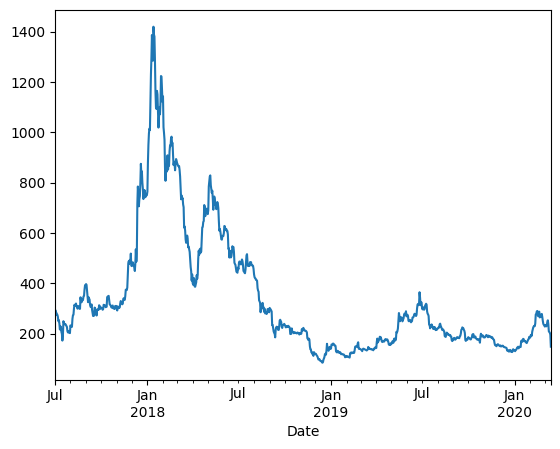

In [ ]:
highs.plot()

__Resampling on the basis of multiple columns__

In [ ]:
df.resample('W').agg({'Close':'mean','High':'max', 'Low':'min', 'Volume':'sum'})

,Close,High,Low,Volume
Date,,,,
2017-07-02,268.202162,293.73,253.23,8.084631e+07
2017-07-09,261.062083,285.00,231.25,2.246746e+08
2017-07-16,195.698393,240.33,130.26,5.017750e+08
2017-07-23,212.783750,249.40,153.25,7.221637e+08
2017-07-30,203.309524,229.99,178.03,2.657305e+08
...,...,...,...,...
2020-02-16,255.198452,290.00,216.31,3.912867e+08
2020-02-23,265.321905,287.13,242.36,3.067838e+08
2020-03-01,236.373988,278.13,209.26,3.693920e+08
